# Notebook for plotting the results of the 2nd extension : Image observations.
Mohammed SBAIHI

## Schedules

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

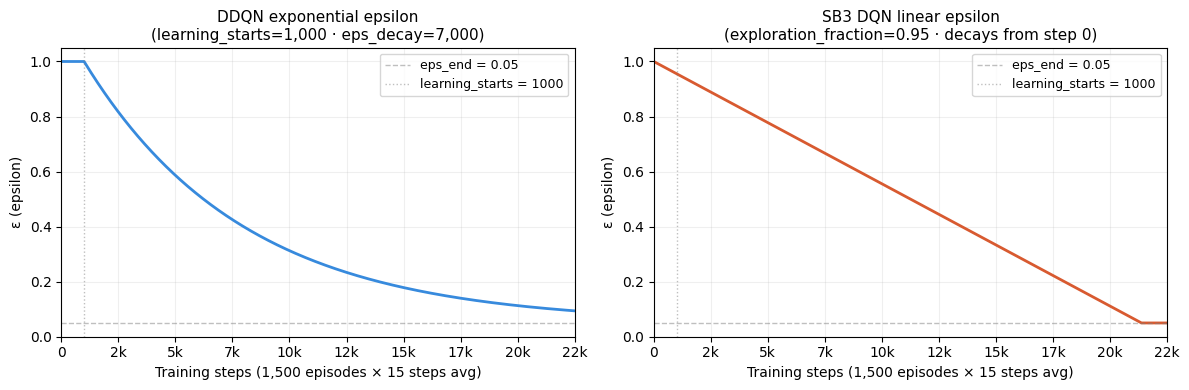

In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np

# --- shared config ---
EPS_START = 1.0
EPS_END = 0.05
TOTAL_STEPS = 22_500

# DDQN exponential
LEARNING_STARTS = 1_000
EPS_DECAY = 7_000

# SB3 DQN linear decays from step 0 over exploration_fraction of total steps
EXPLORATION_FRACTION = 0.95
exploration_steps = EXPLORATION_FRACTION * TOTAL_STEPS  

N = 1000
steps = np.linspace(0, TOTAL_STEPS, N)

# --- exponential schedule (DDQN) ---
# holds at eps_start during warmup, then decays with clock reset to 0
eps_exp = np.where(
    steps < LEARNING_STARTS,
    EPS_START,
    EPS_END + (EPS_START - EPS_END) * np.exp(-(steps - LEARNING_STARTS) / EPS_DECAY)
)

# --- linear schedule (SB3 DQN) ---
# decays from step 0, no warmup hold on epsilon
eps_linear = np.where(
    steps <= exploration_steps,
    EPS_START - (EPS_START - EPS_END) * (steps / exploration_steps),
    EPS_END
)

# --- plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1 - DDQN exponential
axes[0].plot(steps, eps_exp, color='#378ADD', linewidth=2)
axes[0].axhline(y=EPS_END, color='gray', linewidth=1,
                linestyle='--', alpha=0.5, label='eps_end = 0.05')
axes[0].axvline(x=LEARNING_STARTS, color='gray', linewidth=1,
                linestyle=':', alpha=0.5, label=f'learning_starts = {LEARNING_STARTS}')
axes[0].set_title('DDQN exponential epsilon\n'
                  '(learning_starts=1,000 · eps_decay=7,000)', fontsize=11)
axes[0].set_xlabel('Training steps (1,500 episodes × 15 steps avg)', fontsize=10)
axes[0].set_ylabel('ε (epsilon)', fontsize=10)
axes[0].set_ylim(0, 1.05)
axes[0].set_xlim(0, TOTAL_STEPS)
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.2)

# Plot 2 - SB3 DQN linear
axes[1].plot(steps, eps_linear, color='#D85A30', linewidth=2)
axes[1].axhline(y=EPS_END, color='gray', linewidth=1,
                linestyle='--', alpha=0.5, label='eps_end = 0.05')
axes[1].axvline(x=LEARNING_STARTS, color='gray', linewidth=1,
                linestyle=':', alpha=0.5, label=f'learning_starts = {LEARNING_STARTS}')
axes[1].set_title('SB3 DQN linear epsilon\n'
                  '(exploration_fraction=0.95 · decays from step 0)', fontsize=11)
axes[1].set_xlabel('Training steps (1,500 episodes × 15 steps avg)', fontsize=10)
axes[1].set_ylabel('ε (epsilon)', fontsize=10)
axes[1].set_ylim(0, 1.05)
axes[1].set_xlim(0, TOTAL_STEPS)
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('epsilon_schedules_ddqn_sb3.png', dpi=150, bbox_inches='tight')
plt.show()

## DDQN with Big CNN

Total steps taken: 16685


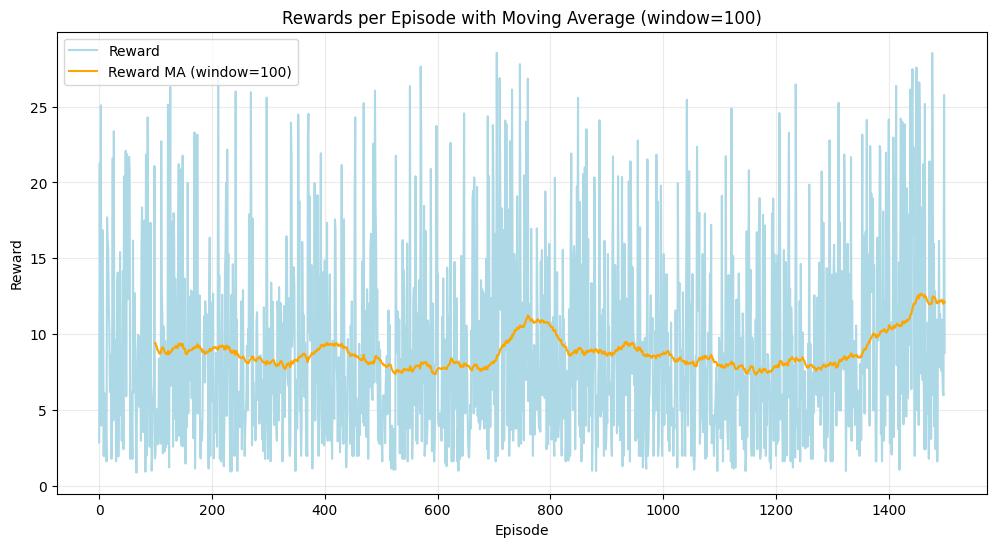

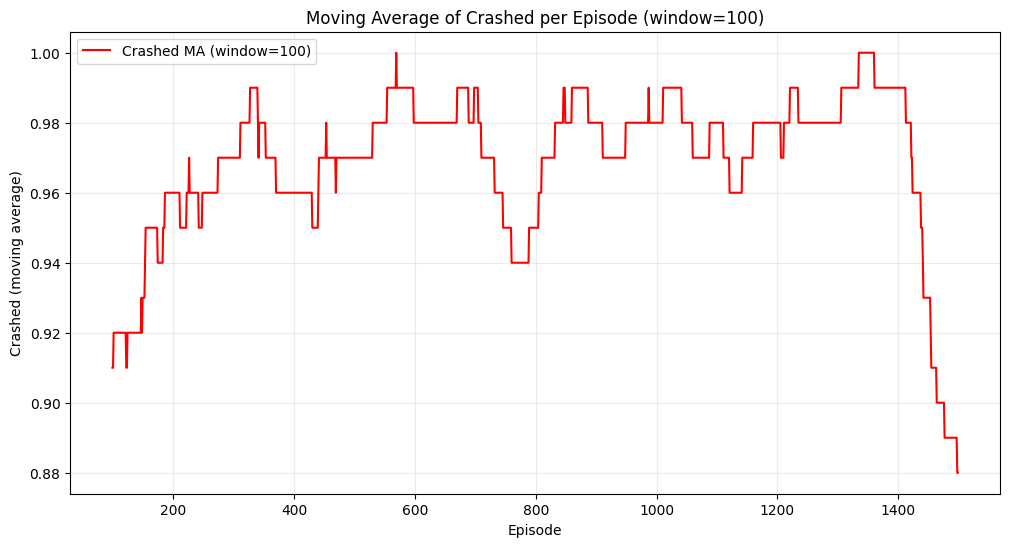

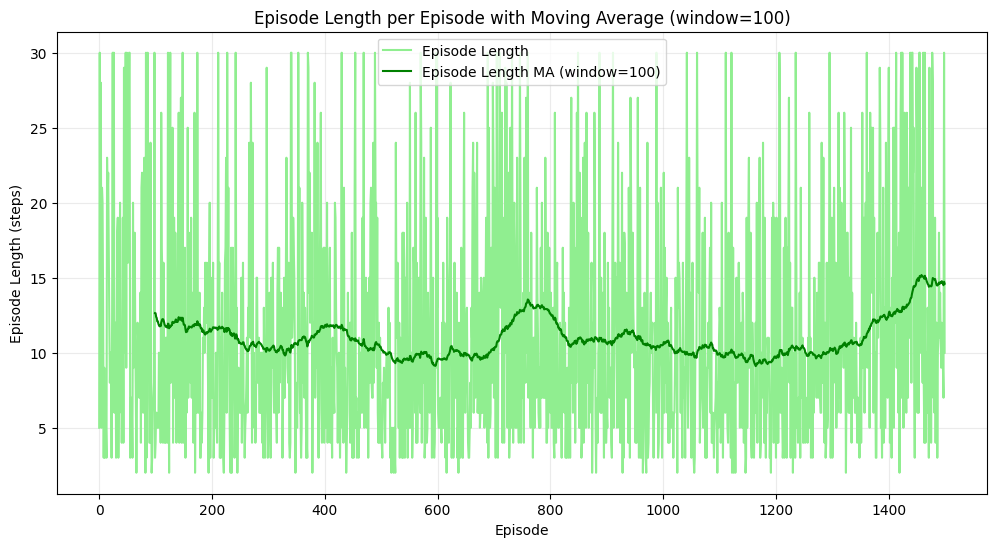

In [46]:
# read training_stats_initial.csv
df_initial = pd.read_csv("training_stats_initial.csv")

# compute moving average of rewards with window of 100 episodes
df_initial["reward_ma100"] = df_initial["reward"].rolling(window=100).mean()

# compute moving average of crashed with window of 100 episodes
df_initial["crashed_ma100"] = df_initial["crashed"].rolling(window=100).mean()

# compute moving average of episode length with window of 100 episodes
df_initial["episode_length_ma100"] = df_initial["length"].rolling(window=100).mean()

# print the number of total steps (sum of episode lengths)
total_steps = df_initial["length"].sum()
print(f"Total steps taken: {total_steps}")

# plot rewards and their moving average
plt.figure(figsize=(12, 6))
plt.plot(df_initial["reward"], color="lightblue", label="Reward")
plt.plot(df_initial["reward_ma100"], color="orange", label="Reward MA (window=100)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Rewards per Episode with Moving Average (window=100)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# plot only the moving average of crashed
plt.figure(figsize=(12, 6))
plt.plot(df_initial["crashed_ma100"], color="red", label="Crashed MA (window=100)")
plt.xlabel("Episode")
plt.ylabel("Crashed (moving average)")
plt.title("Moving Average of Crashed per Episode (window=100)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


# plot episode length and their moving average
plt.figure(figsize=(12, 6))
plt.plot(df_initial["length"], color="lightgreen", label="Episode Length")
plt.plot(df_initial["episode_length_ma100"], color="green", label="Episode Length MA (window=100)")
plt.xlabel("Episode")
plt.ylabel("Episode Length (steps)")
plt.title("Episode Length per Episode with Moving Average (window=100)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## DDQN with small CNN

Total steps taken: 16170


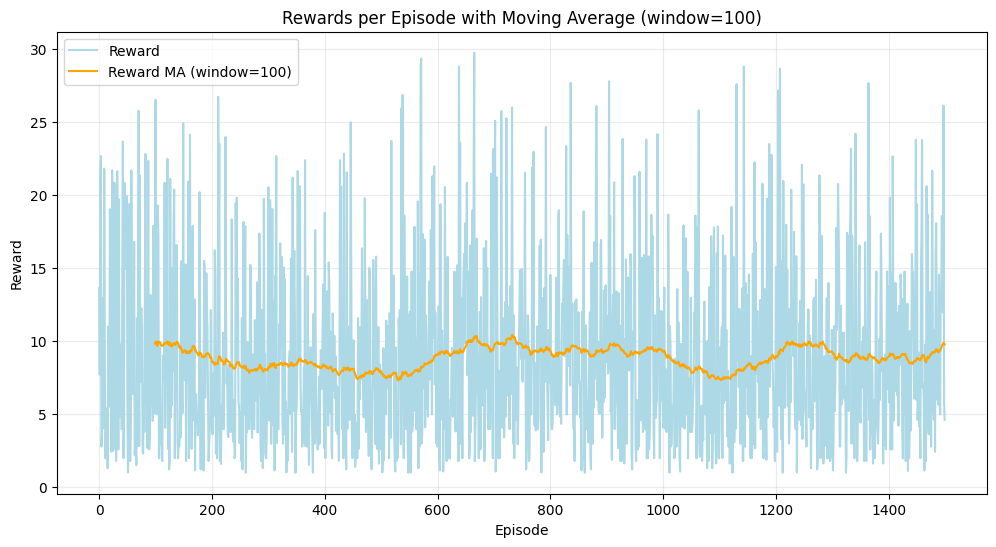

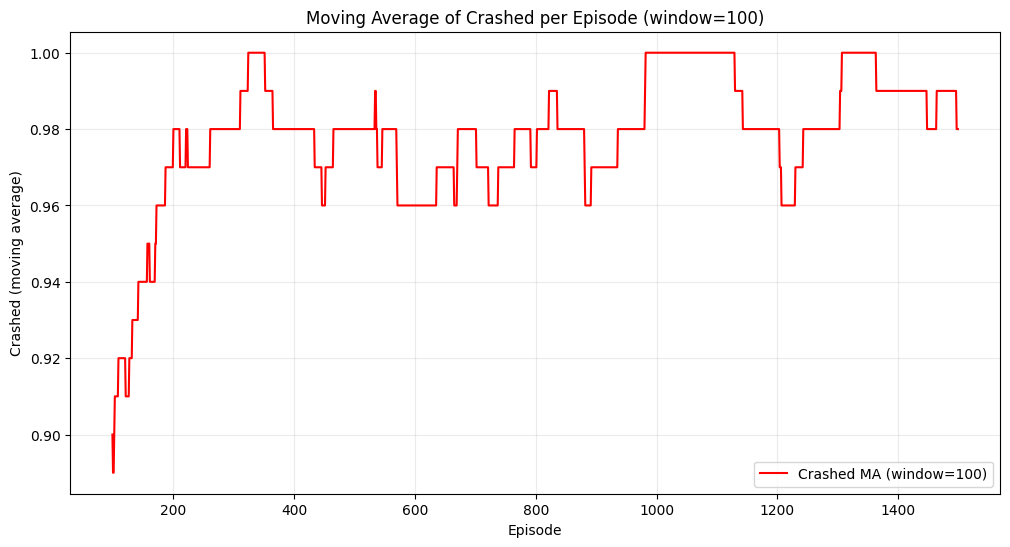

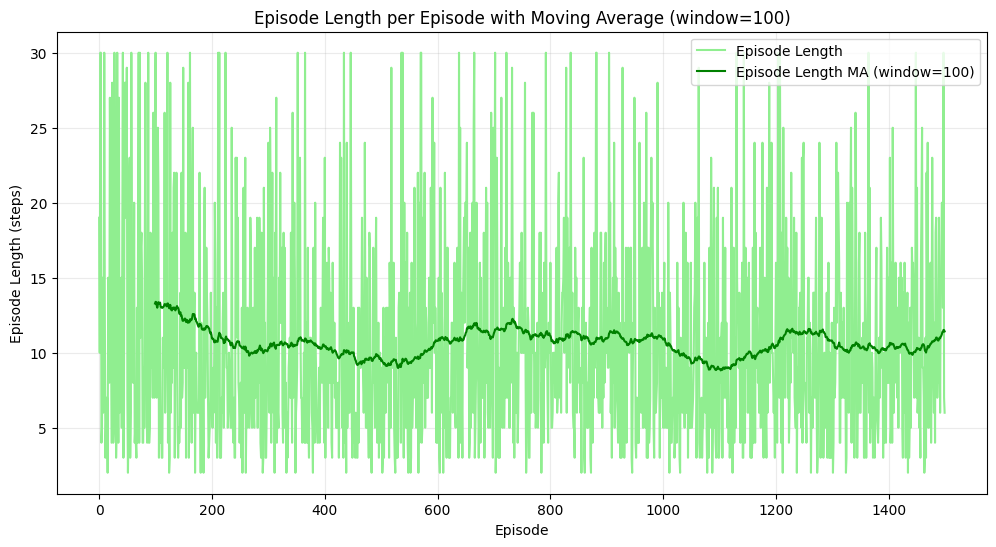

In [47]:
# read training_stats-smallcnn.csv
df_smallcnn = pd.read_csv("training_stats-smallcnn.csv")

# compute moving average of rewards with window of 100 episodes
df_smallcnn["reward_ma100"] = df_smallcnn["reward"].rolling(window=100).mean()

# compute moving average of crashed with window of 100 episodes
df_smallcnn["crashed_ma100"] = df_smallcnn["crashed"].rolling(window=100).mean()

# compute moving average of episode length with window of 100 episodes
df_smallcnn["episode_length_ma100"] = df_smallcnn["length"].rolling(window=100).mean()

total_steps = df_smallcnn["length"].sum()
print(f"Total steps taken: {total_steps}")


# plot rewards and their moving average
plt.figure(figsize=(12, 6))
plt.plot(df_smallcnn["reward"], color="lightblue", label="Reward")
plt.plot(df_smallcnn["reward_ma100"], color="orange", label="Reward MA (window=100)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Rewards per Episode with Moving Average (window=100)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# plot only the moving average of crashed
plt.figure(figsize=(12, 6))
plt.plot(df_smallcnn["crashed_ma100"], color="red", label="Crashed MA (window=100)")
plt.xlabel("Episode")
plt.ylabel("Crashed (moving average)")
plt.title("Moving Average of Crashed per Episode (window=100)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


# plot episode length and their moving average
plt.figure(figsize=(12, 6))
plt.plot(df_smallcnn["length"], color="lightgreen", label="Episode Length")
plt.plot(df_smallcnn["episode_length_ma100"], color="green", label="Episode Length MA (window=100)")
plt.xlabel("Episode")
plt.ylabel("Episode Length (steps)")
plt.title("Episode Length per Episode with Moving Average (window=100)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## SB3 DQN with CnnPolicy

Total steps taken: 17469


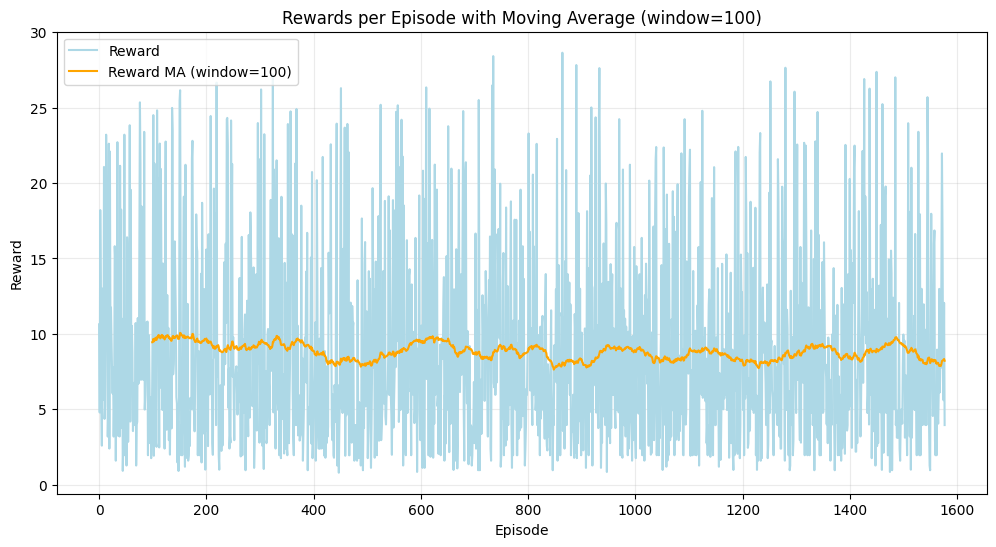

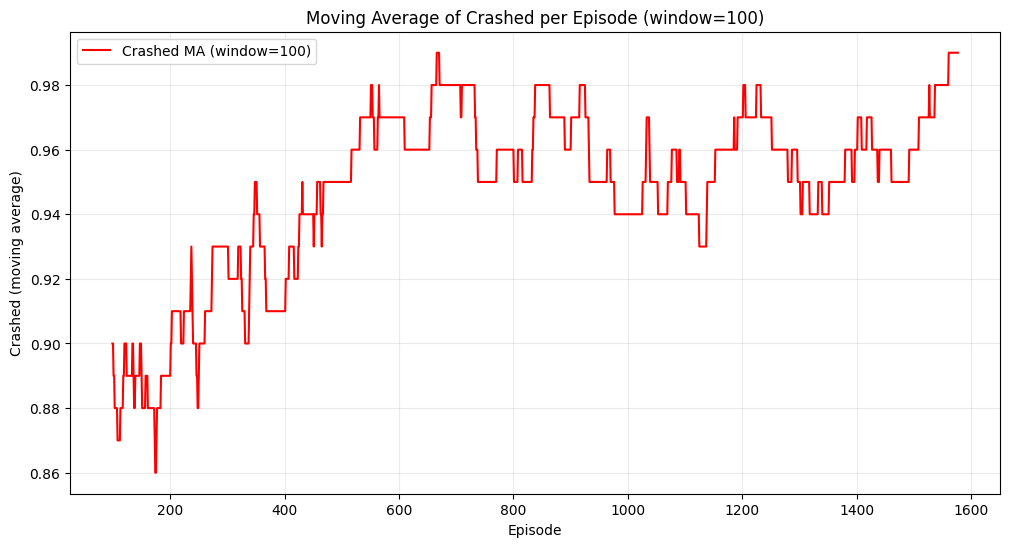

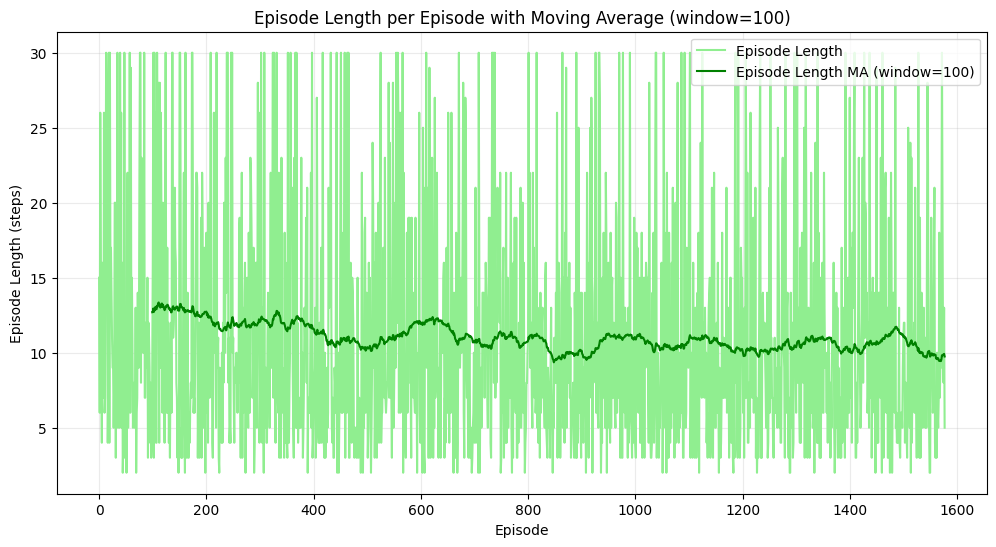

In [48]:
# read training_stats_sb3.csv
df_sb3 = pd.read_csv("training_stats_sb3.csv")

# compute moving average of rewards with window of 100 episodes
df_sb3["reward_ma100"] = df_sb3["reward"].rolling(window=100).mean()

# compute moving average of crashed with window of 100 episodes
df_sb3["crashed_ma100"] = df_sb3["crashed"].rolling(window=100).mean()

# compute moving average of episode length with window of 100 episodes
df_sb3["episode_length_ma100"] = df_sb3["length"].rolling(window=100).mean()

total_steps = df_sb3["length"].sum()
print(f"Total steps taken: {total_steps}")


# plot rewards and their moving average
plt.figure(figsize=(12, 6))
plt.plot(df_sb3["reward"], color="lightblue", label="Reward")
plt.plot(df_sb3["reward_ma100"], color="orange", label="Reward MA (window=100)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Rewards per Episode with Moving Average (window=100)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# plot only the moving average of crashed
plt.figure(figsize=(12, 6))
plt.plot(df_sb3["crashed_ma100"], color="red", label="Crashed MA (window=100)")
plt.xlabel("Episode")
plt.ylabel("Crashed (moving average)")
plt.title("Moving Average of Crashed per Episode (window=100)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


# plot episode length and their moving average
plt.figure(figsize=(12, 6))
plt.plot(df_sb3["length"], color="lightgreen", label="Episode Length")
plt.plot(df_sb3["episode_length_ma100"], color="green", label="Episode Length MA (window=100)")
plt.xlabel("Episode")
plt.ylabel("Episode Length (steps)")
plt.title("Episode Length per Episode with Moving Average (window=100)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## PPO with CnnPolicy

Total steps taken: 60746


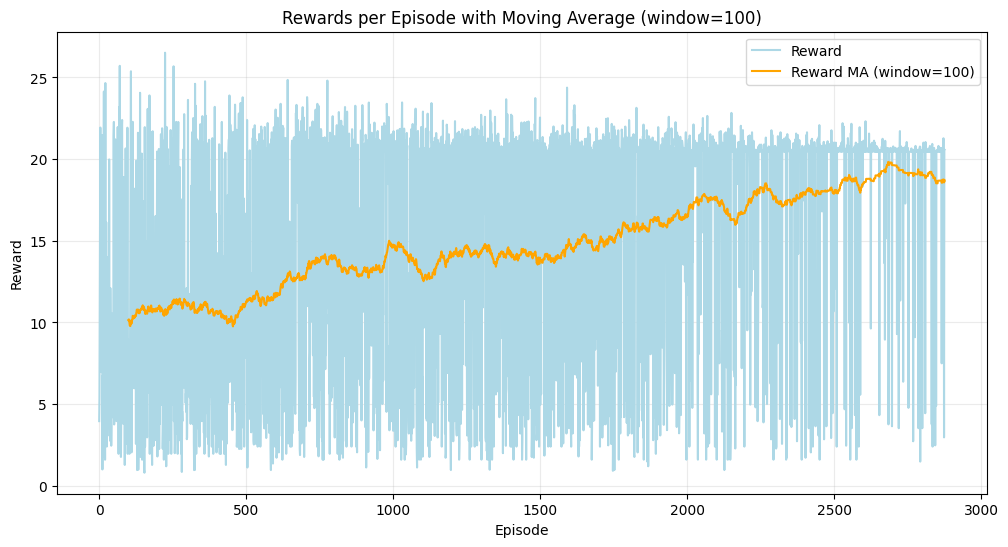

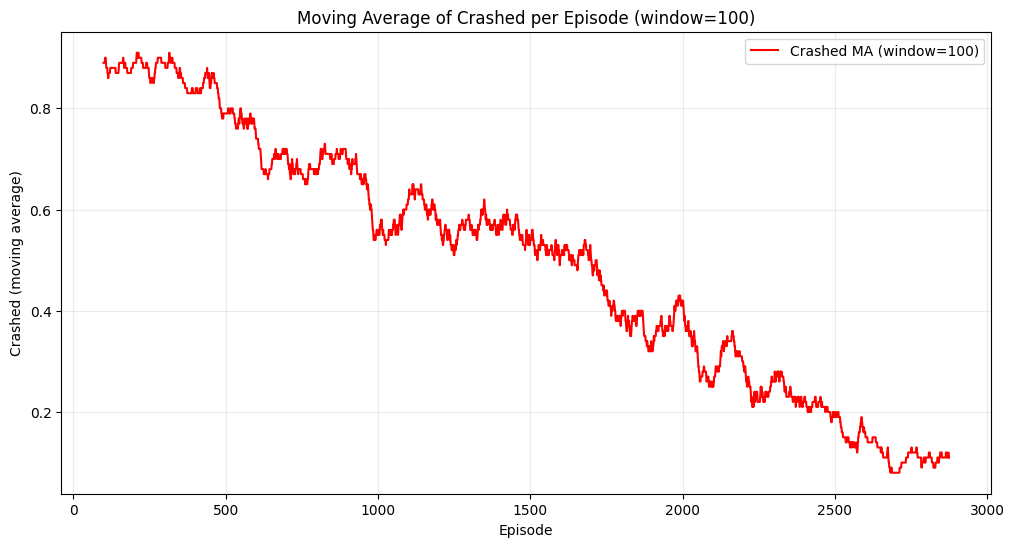

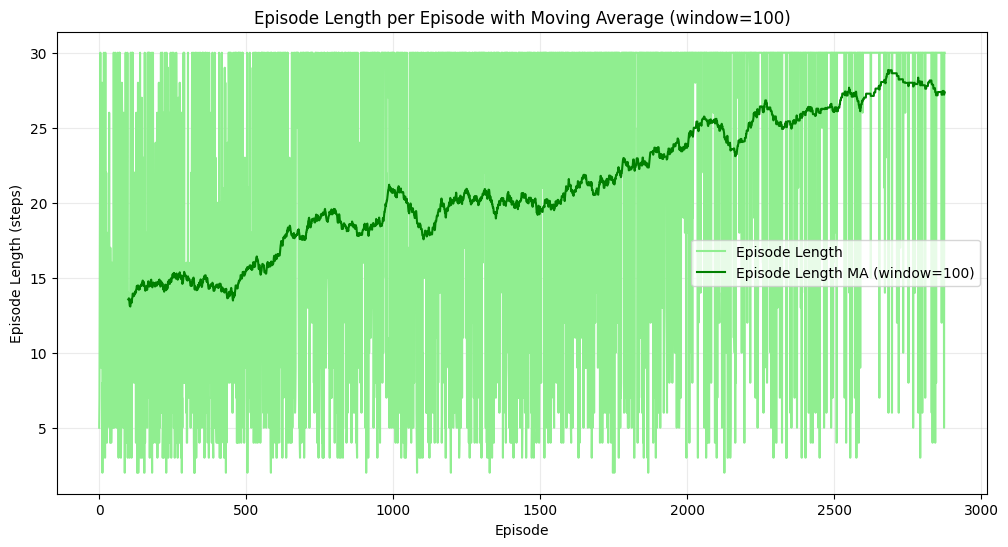

In [5]:
# read training_stats_ppo_cnn.csv
df_ppo = pd.read_csv("training_stats_ppocnn.csv")

# compute moving average of rewards with window of 100 episodes
df_ppo["reward_ma100"] = df_ppo["reward"].rolling(window=100).mean()

# compute moving average of crashed with window of 100 episodes
df_ppo["crashed_ma100"] = df_ppo["crashed"].rolling(window=100).mean()

# compute moving average of episode length with window of 100 episodes
df_ppo["episode_length_ma100"] = df_ppo["length"].rolling(window=100).mean()

total_steps = df_ppo["length"].sum()
print(f"Total steps taken: {total_steps}")


# plot rewards and their moving average
plt.figure(figsize=(12, 6))
plt.plot(df_ppo["reward"], color="lightblue", label="Reward")
plt.plot(df_ppo["reward_ma100"], color="orange", label="Reward MA (window=100)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Rewards per Episode with Moving Average (window=100)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# plot only the moving average of crashed
plt.figure(figsize=(12, 6))
plt.plot(df_ppo["crashed_ma100"], color="red", label="Crashed MA (window=100)")
plt.xlabel("Episode")
plt.ylabel("Crashed (moving average)")
plt.title("Moving Average of Crashed per Episode (window=100)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


# plot episode length and their moving average
plt.figure(figsize=(12, 6))
plt.plot(df_ppo["length"], color="lightgreen", label="Episode Length")
plt.plot(df_ppo["episode_length_ma100"], color="green", label="Episode Length MA (window=100)")
plt.xlabel("Episode")
plt.ylabel("Episode Length (steps)")
plt.title("Episode Length per Episode with Moving Average (window=100)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()